In [5]:
# Importing Libraries
from pathlib import Path
from collections import Counter
import re
import matplotlib.pyplot as plt


# Setting file path
SCRAPPED_FILE_PATH = Path('./scrapped/scrapped-1.txt')
CLEANED_CORPUS_FILE_PATH = Path('./corpus/corpus.txt')

In [6]:
# Number of documents
scraped_text = SCRAPPED_FILE_PATH.read_text(encoding='utf-8', errors='ignore')
doc_count = len(re.findall(r'^===\s*PAGE\s+\d+\s*===', scraped_text, flags=re.MULTILINE))

# Token stats from cleaned corpus
cleaned_text = CLEANED_CORPUS_FILE_PATH.read_text(encoding='utf-8', errors='ignore').strip()
tokens = re.findall(r'[a-z]+', cleaned_text.lower())
total_tokens = len(tokens)
vocab = set(tokens)
vocab_size = len(vocab)

print(f'Documents        : {doc_count}')
print(f'Total tokens     : {total_tokens}')
print(f'Vocabulary size  : {vocab_size}')

# Top-10 words by frequency
top10 = Counter(tokens).most_common(10)
top10_formatted = ", ".join([f"{word}, {count}" for word, count in top10])
print(f'Top-10 words      : {top10_formatted}')

Documents        : 300
Total tokens     : 92383
Vocabulary size  : 7864
Top-10 words      : jodhpur, 1684, department, 1318, iit, 1160, office, 978, engineering, 897, institute, 851, research, 805, iitj, 779, technology, 614, contact, 607


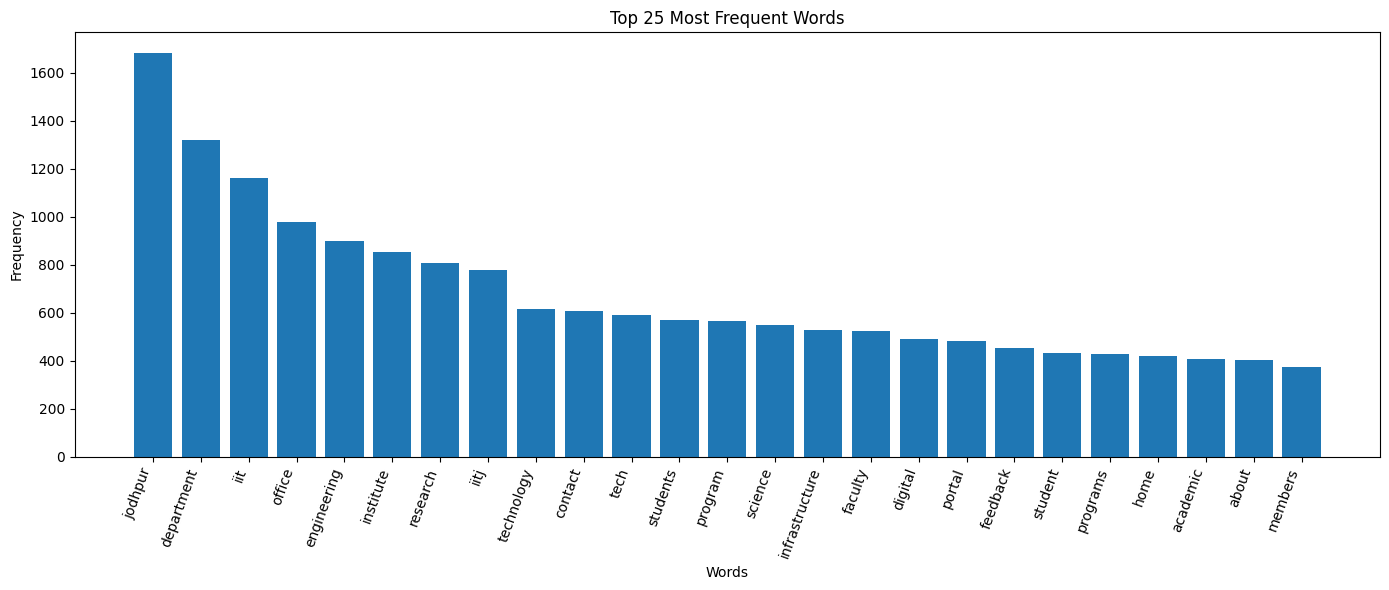

In [7]:
# Most frequent words
top_k = 25
freq = Counter(tokens).most_common(top_k)
words = [w for w, _ in freq]
counts = [c for _, c in freq]

plt.figure(figsize=(14, 6))
plt.bar(words, counts)
plt.xticks(rotation=70, ha='right')
plt.title(f'Top {top_k} Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

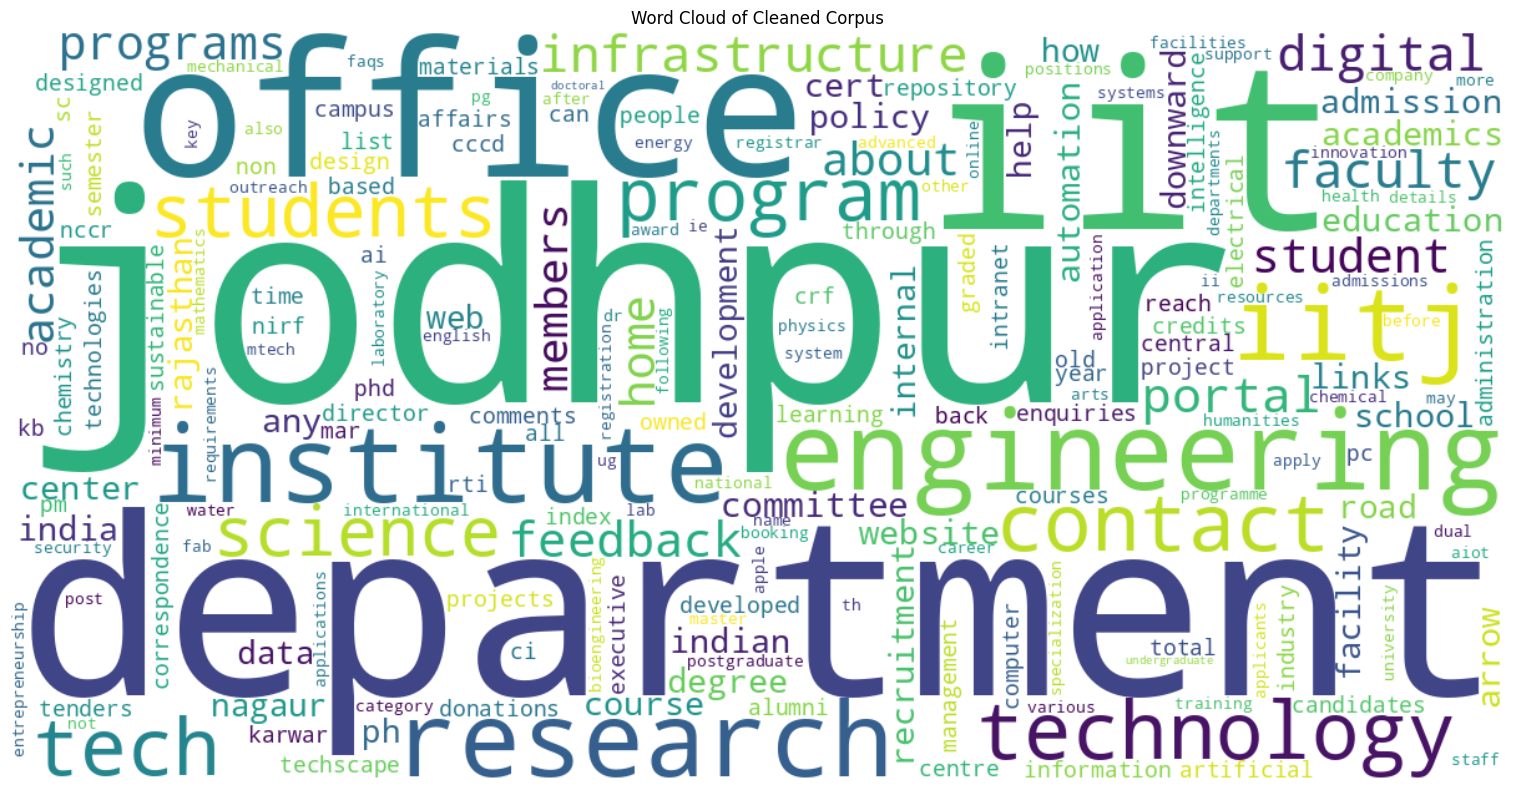

In [8]:
# Word cloud
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(Counter(tokens))

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Corpus')
plt.tight_layout()
plt.show()